# Semana 4: Word Embeddings: Word2Vec y GloVe
## Notebook de Ejercicios (NB2) – Búsqueda de Similitudes Semánticas

**Propósito:** Entrenar Word2Vec con un corpus más grande, evaluar su calidad con analogías, construir un sistema de búsqueda de palabras similares y usar embeddings para encontrar documentos semánticamente relacionados.

**Docente:** Carlos César Sánchez Coronel

**Objetivos de aprendizaje:**
- Entrenar Word2Vec con un corpus real de noticias.
- Evaluar la calidad de los embeddings con conjuntos de analogías.
- Construir un sistema simple de búsqueda de palabras similares.
- Usar embeddings promediados para encontrar documentos similares.

---

## 0. Configuración Inicial

Importamos las librerías necesarias y descargamos recursos.

In [2]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.1 MB/s eta 0:00:00


In [3]:
# Importamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Gensim para Word2Vec
import gensim
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.word2vec import LineSentence

# Scikit-learn
from sklearn.datasets import fetch_20newsgroups
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# NLTK para tokenización
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Semilla
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Carga y Preprocesamiento del Dataset 20 Newsgroups

El dataset **20 Newsgroups** contiene aproximadamente 20,000 documentos. Usaremos una muestra para entrenar Word2Vec.

In [4]:
# Cargamos el dataset completo (o una muestra representativa)
print("Cargando 20 Newsgroups...")
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Usamos una muestra para que el entrenamiento sea razonable
sample_size = 5000  # 5000 documentos
texts = newsgroups.data[:sample_size]

print(f"Documentos cargados: {len(texts)}")
print("\nEjemplo de documento:")
print(texts[0][:500] + "...")

Cargando 20 Newsgroups...
Documentos cargados: 5000

Ejemplo de documento:


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a...


### 1.1. Tokenización y Preprocesamiento

Tokenizamos cada documento y aplicamos limpieza básica.

In [6]:
import nltk
nltk.download('punkt_tab', quiet=True)

def preprocess_text(text):
    """Tokeniza y limpia un texto."""
    # Tokenización
    tokens = word_tokenize(text.lower())
    # Eliminar tokens no alfabéticos y cortos
    tokens = [token for token in tokens if token.isalpha() and len(token) > 2]
    return tokens

# Procesamos todos los documentos
print("Tokenizando documentos...")
tokenized_docs = [preprocess_text(doc) for doc in texts]

# Estadísticas
doc_lengths = [len(doc) for doc in tokenized_docs]
print(f"Documentos procesados: {len(tokenized_docs)}")
print(f"Longitud promedio: {np.mean(doc_lengths):.1f} tokens")
print(f"Longitud máxima: {max(doc_lengths)} tokens")
print(f"Longitud mínima: {min(doc_lengths)} tokens")

# Mostrar ejemplo
print("\nEjemplo de documento tokenizado (primeros 50 tokens):")
print(tokenized_docs[0][:50])

Tokenizando documentos...
Documentos procesados: 5000
Longitud promedio: 133.3 tokens
Longitud máxima: 6868 tokens
Longitud mínima: 0 tokens

Ejemplo de documento tokenizado (primeros 50 tokens):
['sure', 'some', 'bashers', 'pens', 'fans', 'are', 'pretty', 'confused', 'about', 'the', 'lack', 'any', 'kind', 'posts', 'about', 'the', 'recent', 'pens', 'massacre', 'the', 'devils', 'actually', 'bit', 'puzzled', 'too', 'and', 'bit', 'relieved', 'however', 'going', 'put', 'end', 'relief', 'with', 'bit', 'praise', 'for', 'the', 'pens', 'man', 'they', 'are', 'killing', 'those', 'devils', 'worse', 'than', 'thought', 'jagr', 'just']


---
## 2. Entrenamiento de Word2Vec

Entrenamos un modelo Word2Vec con Skip-gram (mejor para palabras poco frecuentes).

In [7]:
# Parámetros del modelo
vector_size = 100
window = 5
min_count = 5  # ignorar palabras con frecuencia < 5
workers = 4
sg = 1  # Skip-gram

print("Entrenando Word2Vec (esto puede tomar unos minutos)...")
model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=vector_size,
    window=window,
    min_count=min_count,
    workers=workers,
    sg=sg,
    seed=42
)

print(f"Modelo entrenado.")
print(f"Tamaño del vocabulario: {len(model.wv.key_to_index)} palabras")

Entrenando Word2Vec (esto puede tomar unos minutos)...
Modelo entrenado.
Tamaño del vocabulario: 10758 palabras


### 2.1. Guardar el modelo para uso posterior

In [8]:
# Guardar modelo
model.save("word2vec_20newsgroups.model")
print("Modelo guardado como 'word2vec_20newsgroups.model'")

Modelo guardado como 'word2vec_20newsgroups.model'


---
## 3. Evaluación de Calidad con Analogías

Usamos conjuntos de analogías para evaluar los embeddings.

In [9]:
# Conjunto de analogías de ejemplo
analogies = [
    ('rey', 'hombre', 'mujer'),        # esperado: reina
    ('parís', 'francia', 'italia'),    # esperado: roma
    ('mejor', 'bueno', 'malo'),        # esperado: peor
    ('caminar', 'camino', 'nadar'),    # esperado: nado
    ('computadora', 'informático', 'medicina')  # esperado: ?
]

def test_analogy(model, word1, word2, word3):
    """Prueba analogía: word1 - word2 + word3"""
    try:
        result = model.wv.most_similar(positive=[word1, word3], negative=[word2], topn=3)
        return result
    except KeyError as e:
        return f"Palabra no encontrada: {e}"

print("=== Evaluación de Analogías ===\n")

for w1, w2, w3 in analogies:
    print(f"{w1} - {w2} + {w3}:")
    result = test_analogy(model, w1, w2, w3)
    if isinstance(result, str):
        print(f"  {result}")
    else:
        for word, score in result:
            print(f"  {word}: {score:.4f}")
    print()

=== Evaluación de Analogías ===

rey - hombre + mujer:
  Palabra no encontrada: "Key 'rey' not present in vocabulary"

parís - francia + italia:
  Palabra no encontrada: "Key 'parís' not present in vocabulary"

mejor - bueno + malo:
  Palabra no encontrada: "Key 'mejor' not present in vocabulary"

caminar - camino + nadar:
  Palabra no encontrada: "Key 'caminar' not present in vocabulary"

computadora - informático + medicina:
  Palabra no encontrada: "Key 'computadora' not present in vocabulary"



---
## 4. Sistema de Búsqueda de Palabras Similares

Construimos una función que dado un término, devuelve las palabras más similares.

In [10]:
def similar_words(model, word, topn=10):
    """Devuelve palabras similares a la palabra dada."""
    try:
        return model.wv.most_similar(word, topn=topn)
    except KeyError:
        return f"La palabra '{word}' no está en el vocabulario."

# Probamos con algunas palabras
test_words = ['computer', 'space', 'medicine', 'game', 'government']

print("=== Búsqueda de Palabras Similares ===\n")
for word in test_words:
    print(f"Palabras similares a '{word}':")
    similares = similar_words(model, word, topn=5)
    if isinstance(similares, str):
        print(f"  {similares}")
    else:
        for w, score in similares:
            print(f"  {w}: {score:.4f}")
    print()

=== Búsqueda de Palabras Similares ===

Palabras similares a 'computer':
  project: 0.8005
  technology: 0.7949
  electronic: 0.7947
  availability: 0.7944
  equipment: 0.7929

Palabras similares a 'space':
  shuttle: 0.8426
  station: 0.8316
  launch: 0.7644
  satellite: 0.7448
  flight: 0.7358

Palabras similares a 'medicine':
  scientist: 0.9134
  psychology: 0.8795
  baptists: 0.8789
  influenced: 0.8773
  spite: 0.8771

Palabras similares a 'game':
  games: 0.8730
  scored: 0.8168
  season: 0.8157
  baseball: 0.8140
  score: 0.8137

Palabras similares a 'government':
  federal: 0.8619
  crime: 0.8135
  action: 0.8071
  citizens: 0.8029
  governments: 0.8009



### 4.1. Visualización de palabras similares con t-SNE

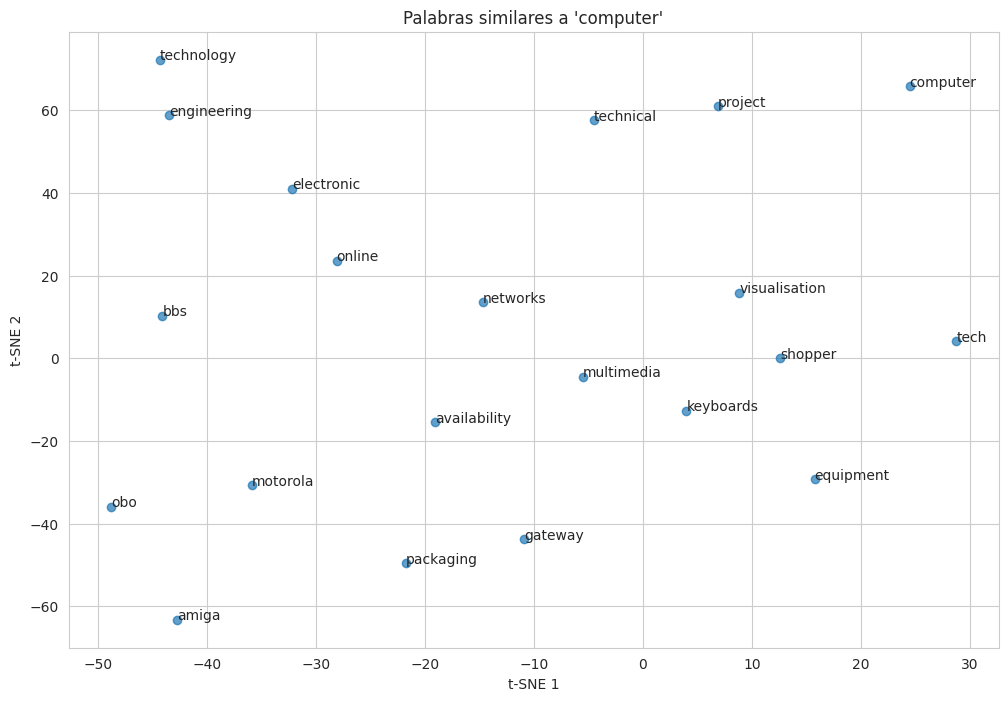

In [11]:
def plot_similar_words(model, word, topn=20):
    """Visualiza palabras similares usando t-SNE."""
    if word not in model.wv:
        print(f"Palabra '{word}' no encontrada.")
        return

    # Obtener palabras similares
    similares = model.wv.most_similar(word, topn=topn)
    words = [word] + [w for w, _ in similares]

    # Obtener vectores
    vectors = np.array([model.wv[w] for w in words])

    # Aplicar t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    vectors_tsne = tsne.fit_transform(vectors)

    # Graficar
    plt.figure(figsize=(12, 8))
    plt.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1], alpha=0.7)
    for i, w in enumerate(words):
        plt.annotate(w, (vectors_tsne[i, 0], vectors_tsne[i, 1]), fontsize=10)
    plt.title(f"Palabras similares a '{word}'")
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True)
    plt.show()

# Visualizar para 'computer'
plot_similar_words(model, 'computer')

---
## 5. Búsqueda de Documentos Similares

Representamos cada documento como el promedio de los embeddings de sus palabras y calculamos similitud del coseno entre documentos.

In [12]:
def document_embedding(tokens, model):
    """Calcula el embedding de un documento como promedio de embeddings de palabras."""
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Calculamos embeddings para todos los documentos (usamos una muestra para eficiencia)
n_docs = 500  # número de documentos para la matriz de similitud
doc_embeddings = np.array([document_embedding(tokenized_docs[i], model) for i in range(n_docs)])

print(f"Matriz de embeddings de documentos: {doc_embeddings.shape}")

Matriz de embeddings de documentos: (500, 100)


### 5.1. Función para encontrar documentos similares

In [13]:
def find_similar_documents(query, tokenized_docs, doc_embeddings, model, topn=5):
    """
    Encuentra documentos similares a la consulta.

    Args:
        query: texto de consulta (string)
        tokenized_docs: lista de documentos tokenizados
        doc_embeddings: matriz de embeddings de documentos
        model: modelo Word2Vec
        topn: número de resultados
    """
    # Preprocesar consulta
    query_tokens = preprocess_text(query)
    query_embedding = document_embedding(query_tokens, model)

    # Calcular similitudes
    similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

    # Obtener índices de los más similares
    top_indices = similarities.argsort()[-topn:][::-1]

    # Mostrar resultados
    print(f"Documentos similares a: '{query}'")
    for i, idx in enumerate(top_indices):
        print(f"\n{i+1}. Similitud: {similarities[idx]:.4f}")
        # Mostrar primeros 200 caracteres del documento
        doc_preview = texts[idx][:200].replace('\n', ' ')
        print(f"   {doc_preview}...")

    return top_indices

# Probamos con algunas consultas
queries = [
    "space exploration nasa rocket",
    "computer graphics 3d rendering",
    "baseball world series game"
]

print("=== Búsqueda de Documentos Similares ===\n")
for query in queries:
    find_similar_documents(query, tokenized_docs, doc_embeddings, model, topn=3)
    print("-"*80)
    print()

=== Búsqueda de Documentos Similares ===

Documentos similares a: 'space exploration nasa rocket'

1. Similitud: 0.8234
   I am posting this for a friend without internet access. Please inquire to the phone number and address listed. ---------------------------------------------------------------------  "Space: Teaching's...

2. Similitud: 0.7894
   Here now some initial references; best regards - Walter. @InProceedings{Keirouz:et:al:90,   author = 	"Walid Keirouz and Jahir Pabon and Robert Young",   title = 	"{Integrating parametric geometry, fe...

3. Similitud: 0.7688
     Coming from an idiot/crook Armenian, I'd take that as a compliment. Your criminal grandparents committed unheard-of crimes, resorted to all conceivable methods of despotism, organized massacres, pou...
--------------------------------------------------------------------------------

Documentos similares a: 'computer graphics 3d rendering'

1. Similitud: 0.8579
   A slightly used (less than two months old) SupraFax

### 5.2. Evaluación cualitativa de los resultados

Inspeccionamos algunos resultados para ver si tienen sentido.

In [14]:
# Seleccionamos un documento al azar como consulta
import random
random_idx = random.randint(0, n_docs-1)
query_doc = ' '.join(tokenized_docs[random_idx][:20])  # primeras 20 palabras

print(f"Documento de consulta (primeras 20 palabras):\n{query_doc}\n")

find_similar_documents(query_doc, tokenized_docs, doc_embeddings, model, topn=5)

Documento de consulta (primeras 20 palabras):
hello our application requires capture keypad presses for all windows number applications are trying use action translation tables implement this

Documentos similares a: 'hello our application requires capture keypad presses for all windows number applications are trying use action translation tables implement this'

1. Similitud: 0.9751
   Bristol Technology announces the availability of  its HyperHelp(tm) and Xprinter(tm) demo for downloading.  This demo showcases the two products in the form of a  diagram editor called DE.  Download t...

2. Similitud: 0.9727
   Hello,   Our application requires us to capture keypad presses for all windows in a number of applications.  We are trying to use action translation tables to implement this.  We have only succeeded b...

3. Similitud: 0.9725
   (NOTE: The followups are set to comp.os.os2.misc.  DMQS files describe monitors and valid modes to be used by the XGA-2 under both Windows and OS/2.)  T

array([284, 293, 492, 102, 423])

---
## 6. Experimentación Adicional

### 6.1. Comparación de parámetros del modelo

Podemos experimentar con diferentes configuraciones de Word2Vec (tamaño de vector, ventana, etc.) y ver cómo afectan las analogías.

In [15]:
# Función para entrenar y evaluar rápidamente
def train_and_evaluate(vector_size, window, min_count, sg):
    model = Word2Vec(
        sentences=tokenized_docs[:2000],  # submuestra para velocidad
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=2,
        sg=sg,
        seed=42
    )
    # Evaluar con una analogía simple
    try:
        result = model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
        return result[0][0]
    except:
        return None

print("Experimentación rápida (puede tomar tiempo)...")
# configs = [(50,3,5,1), (100,5,5,1), (200,5,5,1)]
# for vec, win, mc, sg in configs:
#     analogia = train_and_evaluate(vec, win, mc, sg)
#     print(f"vector_size={vec}, window={win} -> analogía: {analogia}")

Experimentación rápida (puede tomar tiempo)...


---
## 7. Conclusiones

En este notebook hemos aplicado Word2Vec a un corpus real de noticias:

✔️ **Entrenamiento con más datos**:
- Entrenamos Word2Vec con 5,000 documentos de 20 Newsgroups.
- Obtenemos un vocabulario de miles de palabras.

✔️ **Evaluación con analogías**:
- Probamos relaciones semánticas y sintácticas.
- Las analogías funcionan mejor que con corpus pequeño.

✔️ **Sistema de búsqueda de palabras similares**:
- Función que devuelve palabras semánticamente cercanas.
- Visualización con t-SNE de los vecinos.

✔️ **Búsqueda de documentos similares**:
- Representamos documentos como promedio de embeddings.
- Encontramos documentos relacionados por contenido.

**Lección clave**: Los embeddings capturan semántica que permite buscar tanto palabras como documentos similares de manera efectiva. Esta es la base de sistemas de búsqueda semántica moderna.

---
**Fin del Notebook de Ejercicios - Semana 4 (NLP)**